# Question 2 - Dimension Reduction using Autoencoder

## Dataset: Oil Gas Field (Overhead-MNIST)

Dataset yang digunakan pada penelitian ini adalah kelas **Oil Gas Field** dari dataset **Overhead-MNIST**. Dataset ini berisi gambar grayscale berukuran **28×28 piksel** yang merepresentasikan area ladang minyak dan gas yang diambil dari gambar penginderaan jauh (overhead imagery).

Sesuai dengan instruksi pada soal, tujuan utama penelitian ini bukan untuk melakukan klasifikasi gambar, melainkan melakukan **dimension reduction** menggunakan arsitektur **Autoencoder**. Teknik dimension reduction bertujuan untuk mengurangi jumlah fitur pada gambar tanpa menghilangkan informasi penting yang diperlukan untuk merepresentasikan objek.

Pada dataset ini, setiap gambar memiliki ukuran:

* 28 × 28 = 784 fitur

Melalui proses encoding pada Autoencoder, gambar akan dikompresi menjadi representasi laten (latent representation) berukuran:

* 128 fitur

Sehingga terjadi pengurangan dimensi sebesar:

* 784 → 128 fitur
* Reduksi dimensi sebesar 83.67%

Representasi laten tersebut diharapkan mampu menyimpan informasi penting dari gambar Oil Gas Field meskipun jumlah fitur telah berkurang secara signifikan. Selanjutnya, decoder akan merekonstruksi kembali gambar dari representasi laten tersebut sehingga kualitas hasil rekonstruksi dapat dievaluasi.

Tahapan penelitian yang dilakukan meliputi:

* Loading dataset Oil Gas Field
* Normalisasi (scaling) nilai piksel ke rentang 0–1
* Menampilkan beberapa contoh gambar dari dataset
* Membagi dataset menjadi:

  * 80% Training Set
  * 10% Validation Set
  * 10% Test Set
* Membangun arsitektur baseline Autoencoder sesuai spesifikasi soal
* Melatih model menggunakan data training
* Melakukan rekonstruksi gambar pada data test
* Mengevaluasi kualitas gambar hasil rekonstruksi menggunakan Structural Similarity Index (SSIM)

Structural Similarity Index (SSIM) digunakan untuk mengukur tingkat kemiripan antara gambar asli dan gambar hasil rekonstruksi. Nilai SSIM berada pada rentang 0 hingga 1, dimana nilai yang semakin mendekati 1 menunjukkan bahwa informasi yang dipertahankan oleh representasi laten semakin baik dan gambar hasil rekonstruksi semakin mirip dengan gambar asli.

Pada tahap berikutnya, arsitektur Autoencoder akan dimodifikasi dan dilakukan proses tuning hyperparameter untuk memperoleh representasi fitur yang lebih optimal serta meningkatkan nilai SSIM dibandingkan model baseline.


# 2a. Loading, Scaling, dan Data Split

In [1]:
# Import Libraries

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

from skimage.metrics import structural_similarity as ssim

In [2]:
# Load Gambar oil gas field
stadium_train = glob.glob(
    "version2/train/oil_gas_field/*.jpg"
)

stadium_test = glob.glob(
    "version2/test/stadium/*.jpg"
)

all_stadium = stadium_train + stadium_test

print("Total Images :", len(all_stadium))

Total Images : 7953


In [3]:
# Resize and Scaling
images = []

for img_path in all_stadium:
    img = Image.open(img_path).convert('L')
    img = np.array(img)

    images.append(img)

images = np.array(images)

print(images.shape)

(7953, 28, 28)


In [4]:
images = images.astype("float32") / 255.0

In [5]:
# Tambahkan Channel
images = np.expand_dims(images, axis=-1)

print(images.shape)

(7953, 28, 28, 1)


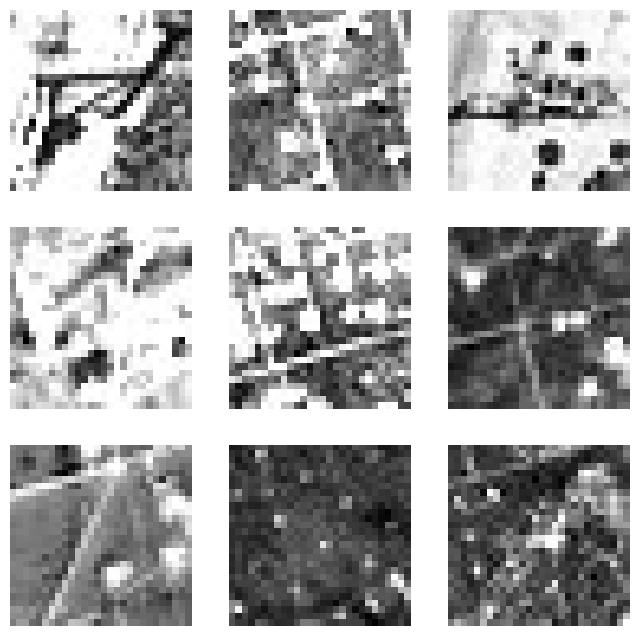

In [6]:
# Tampilan Contoh Data
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

Split 80/10/10
Train 80%
Validation 10%
Test 10%

In [7]:
X_train, X_temp = train_test_split(
    images,
    test_size=0.20,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (6362, 28, 28, 1)
Val   : (795, 28, 28, 1)
Test  : (796, 28, 28, 1)


## Data Splitting

Dataset **Oil Gas Field** yang digunakan terdiri dari **7.953 gambar grayscale** berukuran **28×28 piksel**.

Sebelum proses pelatihan, seluruh gambar dinormalisasi ke rentang nilai **0–1** dengan membagi setiap nilai piksel dengan **255**. Proses normalisasi dilakukan untuk mempercepat konvergensi model, meningkatkan stabilitas training, serta memastikan setiap fitur berada pada skala yang seragam.

Sesuai dengan instruksi pada soal, dataset kemudian dibagi menjadi tiga bagian dengan proporsi **80% data training, 10% data validation, dan 10% data testing**. Hasil pembagian dataset adalah sebagai berikut:

* **Data Training:** 6.362 gambar (80%)
* **Data Validation:** 795 gambar (10%)
* **Data Testing:** 796 gambar (10%)

Data training digunakan untuk melatih parameter Autoencoder agar mampu mempelajari representasi laten dari gambar Oil Gas Field. Data validation digunakan untuk memantau performa model selama proses training dan membantu mendeteksi potensi overfitting. Sementara itu, data testing digunakan sebagai data yang belum pernah dilihat model sebelumnya dan digunakan untuk mengevaluasi kualitas hasil rekonstruksi menggunakan metrik **Structural Similarity Index (SSIM)**.


In [8]:
print(X_train.min(), X_train.max())

0.0 1.0


# 2b Baseline Autoencoder

In [9]:
# Encoder
input_img = layers.Input(shape=(28,28,1))

x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = layers.Flatten()(x)

encoded = layers.Dense(
    128,
    activation='relu',
    name='latent_vector'
)(x)

In [10]:
# Decoder
x = layers.Dense(
    14*14*32,
    activation='relu'
)(encoded)

x = layers.Reshape((14,14,32))(x)

x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [11]:
# Build Model
autoencoder = Model(
    input_img,
    decoded
)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,612,641 (6.15 MB)

 Trainable params: 1,612,641 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Training
history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0336 - val_loss: 0.0255
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0225 - val_loss: 0.0206
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0190 - val_loss: 0.0182
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0172 - val_loss: 0.0169
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0161 - val_loss: 0.0160
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0154 - val_loss: 0.0156
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0151 - val_loss: 0.0155
Epoch 8/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0148 - val_loss: 0.0154
Epoch 9/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0146 - val_loss: 0.0151
Epoch 10/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0145 - val_loss: 0.0152
Epoch 11/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0144 - val_loss: 0.0150
Epoch 12/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 1

In [13]:
# Reconstruction
reconstructed = autoencoder.predict(X_test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


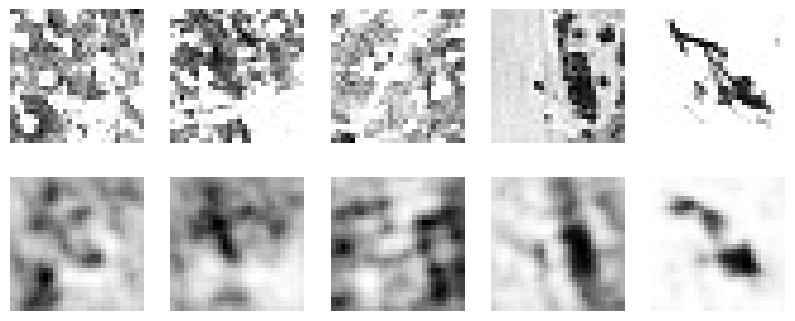

In [14]:
# visualisasi hasil decoder
n = 5

plt.figure(figsize=(10,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(
        reconstructed[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

plt.show()

In [15]:
ssim_scores = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        reconstructed[i].squeeze(),
        data_range=1.0
    )

    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print("Average SSIM:", mean_ssim)

Average SSIM: 0.48271439672874983


## Evaluasi Baseline Autoencoder Menggunakan SSIM

Setelah model Autoencoder baseline dilatih menggunakan dataset **Oil Gas Field**, dilakukan evaluasi terhadap kualitas gambar hasil rekonstruksi menggunakan metrik **Structural Similarity Index (SSIM)**.

Hasil evaluasi menunjukkan bahwa model memperoleh nilai rata-rata **SSIM sebesar 0.4827** pada data test.

Nilai SSIM berada pada rentang 0 hingga 1, dimana nilai yang semakin mendekati 1 menunjukkan bahwa gambar hasil rekonstruksi semakin mirip dengan gambar asli. Sebaliknya, nilai yang lebih rendah menunjukkan bahwa masih terdapat perbedaan yang cukup signifikan antara gambar asli dan gambar hasil rekonstruksi.

Nilai SSIM sebesar **0.4827** menunjukkan bahwa Autoencoder baseline telah mampu mempelajari sebagian karakteristik utama dari gambar Oil Gas Field, namun kualitas rekonstruksi yang dihasilkan masih belum optimal. Beberapa informasi visual dan detail struktural pada gambar belum dapat direpresentasikan dengan baik oleh representasi laten yang dihasilkan model.

Hasil ini menunjukkan bahwa dataset Oil Gas Field memiliki karakteristik visual yang lebih kompleks dibandingkan yang dapat ditangkap oleh arsitektur baseline. Oleh karena itu, diperlukan modifikasi arsitektur dan tuning hyperparameter untuk meningkatkan kemampuan model dalam mempertahankan informasi penting selama proses dimension reduction.

Nilai SSIM baseline ini selanjutnya digunakan sebagai acuan untuk mengevaluasi efektivitas model Autoencoder yang telah dimodifikasi pada tahap berikutnya.


## Kesimpulan Baseline Autoencoder

Autoencoder baseline berhasil melakukan proses **dimension reduction** dari 784 dimensi (28×28 piksel) menjadi representasi laten berukuran 128 dimensi pada dataset Oil Gas Field.

Model menghasilkan nilai rata-rata **SSIM sebesar 0.4827** pada data test. Hasil ini menunjukkan bahwa model telah mampu melakukan rekonstruksi gambar, namun masih terdapat kehilangan informasi yang cukup signifikan sehingga kualitas rekonstruksi belum sepenuhnya menyerupai gambar asli.

Nilai SSIM yang relatif rendah mengindikasikan bahwa arsitektur baseline masih memiliki keterbatasan dalam menangkap karakteristik visual yang terdapat pada gambar Oil Gas Field. Oleh karena itu, diperlukan pengembangan arsitektur yang lebih kompleks serta proses tuning hyperparameter untuk memperoleh representasi fitur yang lebih informatif dan meningkatkan kualitas rekonstruksi gambar.

Pada tahap selanjutnya akan dilakukan modifikasi arsitektur Autoencoder dan optimasi hyperparameter untuk meningkatkan nilai SSIM dibandingkan model baseline.


# 2c. Modifikasi Arsitektur Autoencoder dan Hyperparameter Tuning

Hasil evaluasi pada model baseline menunjukkan bahwa Autoencoder hanya memperoleh nilai **SSIM sebesar 0.4827**. Nilai tersebut jauh lebih rendah dibandingkan hasil yang diperoleh pada dataset Stadium, sehingga menunjukkan bahwa gambar Oil Gas Field memiliki tingkat kompleksitas yang lebih tinggi untuk direkonstruksi.

Secara visual, gambar Oil Gas Field memiliki pola tekstur, bentuk area, serta distribusi objek yang lebih bervariasi dibandingkan gambar Stadium. Akibatnya, representasi laten yang dihasilkan oleh Autoencoder baseline belum mampu menyimpan informasi visual yang cukup untuk menghasilkan rekonstruksi yang akurat.

Berdasarkan kondisi tersebut, dilakukan pengembangan arsitektur Autoencoder dengan pendekatan yang berbeda dari eksperimen sebelumnya. Fokus utama modifikasi ini adalah meningkatkan kemampuan model dalam menangkap detail tekstur dan pola spasial yang terdapat pada gambar Oil Gas Field.

Perubahan yang dilakukan meliputi:

1. Menambahkan layer Convolutional hingga 256 filter untuk memperkaya proses ekstraksi fitur.
2. Memperdalam struktur encoder dan decoder agar model mampu mempelajari pola visual yang lebih kompleks.
3. Menambahkan Batch Normalization untuk meningkatkan stabilitas training.
4. Menambahkan Dropout untuk mengurangi risiko overfitting.
5. Menggunakan fungsi loss Mean Absolute Error (MAE) yang lebih sensitif terhadap perbedaan detail piksel pada hasil rekonstruksi.
6. Menyesuaikan learning rate, batch size, dan jumlah epoch melalui proses hyperparameter tuning.

Arsitektur yang lebih dalam dipilih karena karakteristik gambar Oil Gas Field mengandung lebih banyak variasi tekstur dibandingkan gambar Stadium. Dengan jumlah filter yang lebih besar, model diharapkan mampu mengekstraksi fitur yang lebih representatif sehingga informasi penting pada gambar tetap dapat dipertahankan meskipun telah mengalami proses dimension reduction.

Melalui modifikasi ini diharapkan nilai SSIM yang diperoleh dapat meningkat dibandingkan model baseline, sehingga kualitas gambar hasil rekonstruksi menjadi lebih mendekati gambar asli.


In [16]:
# Build Improved Autoencoder Oil Gas
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# ==========================
# ENCODER
# ==========================

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    256,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Flatten()(x)

x = Dropout(0.15)(x)

latent = Dense(
    128,
    activation='relu',
    name='latent_vector'
)(x)

# ==========================
# DECODER
# ==========================

x = Dense(
    7 * 7 * 256,
    activation='relu'
)(latent)

x = Reshape((7,7,256))(x)

x = Conv2D(
    256,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

oil_autoencoder = Model(
    input_img,
    decoded
)

oil_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12544)          │     1,618,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        73,79

 Total params: 4,593,153 (17.52 MB)

 Trainable params: 4,591,297 (17.51 MB)

 Non-trainable params: 1,856 (7.25 KB)

In [17]:
# Compile model
from tensorflow.keras.optimizers import Adam

oil_autoencoder.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='mae'
)

In [ ]:
# Early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [19]:
# Training
history_oil = oil_autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - loss: 0.1229 - val_loss: 0.2681
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step - loss: 0.1008 - val_loss: 0.2609
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - loss: 0.0947 - val_loss: 0.2421
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - loss: 0.0907 - val_loss: 0.1931
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - loss: 0.0885 - val_loss: 0.1406
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step - loss: 0.0862 - val_loss: 0.0938
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - loss: 0.0842 - val_loss: 0.0854
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - loss: 0.0822 - val_loss: 0.0831
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - loss: 0.0805 - val_loss: 0.0825
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - loss: 0.0803 - val_loss: 0.0812
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - loss: 0.0781 - val_loss: 0.0803
Epoch 12

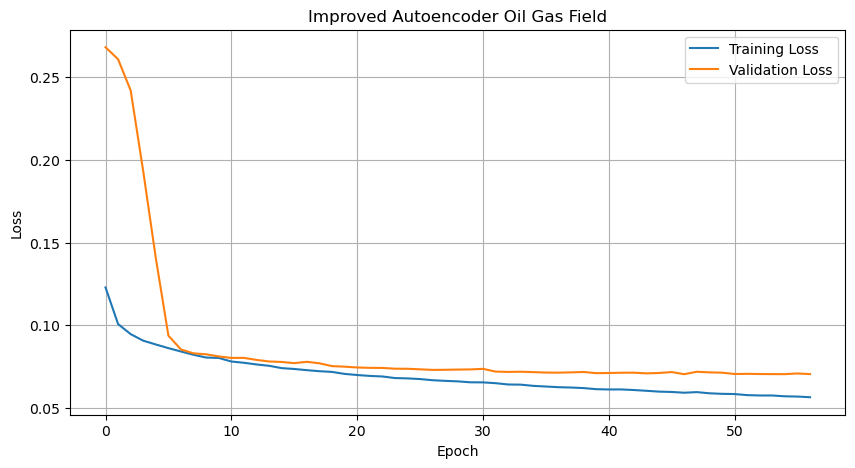

In [20]:
#visualisasi loss
plt.figure(figsize=(10,5))

plt.plot(
    history_oil.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_oil.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Improved Autoencoder Oil Gas Field'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

### Improved Model Training Analysis

Berdasarkan grafik training history, nilai **training loss** mengalami penurunan secara konsisten selama proses pelatihan. Penurunan yang stabil ini menunjukkan bahwa model berhasil mempelajari representasi fitur dari data secara bertahap.

Sementara itu, **validation loss** mengalami penurunan yang sangat tajam pada beberapa epoch pertama, kemudian cenderung stabil pada kisaran sekitar **0.07** hingga akhir proses training. Pola ini menunjukkan bahwa model dengan cepat menemukan representasi yang baik pada data validasi dan tidak mengalami peningkatan error yang signifikan pada epoch berikutnya.

Perbedaan antara training loss dan validation loss relatif kecil setelah model mencapai kondisi stabil. Hal ini mengindikasikan bahwa model tidak menunjukkan gejala **overfitting** yang berarti, sehingga memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Selain itu, kurva training dan validation loss sama-sama menunjukkan kecenderungan konvergen tanpa fluktuasi yang berlebihan. Kondisi ini menandakan bahwa proses optimasi berjalan dengan baik dan model berhasil mencapai solusi yang stabil.

Secara keseluruhan, hasil training menunjukkan bahwa arsitektur **Improved Autoencoder** mampu menghasilkan proses pembelajaran yang lebih stabil dan efektif dalam merekonstruksi citra pada dataset **Oil Gas Field**, sehingga model layak digunakan untuk tahap evaluasi menggunakan metrik SSIM.

In [21]:
#Reconstruction
reconstructed_oil = oil_autoencoder.predict(
    X_test
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 299ms/step


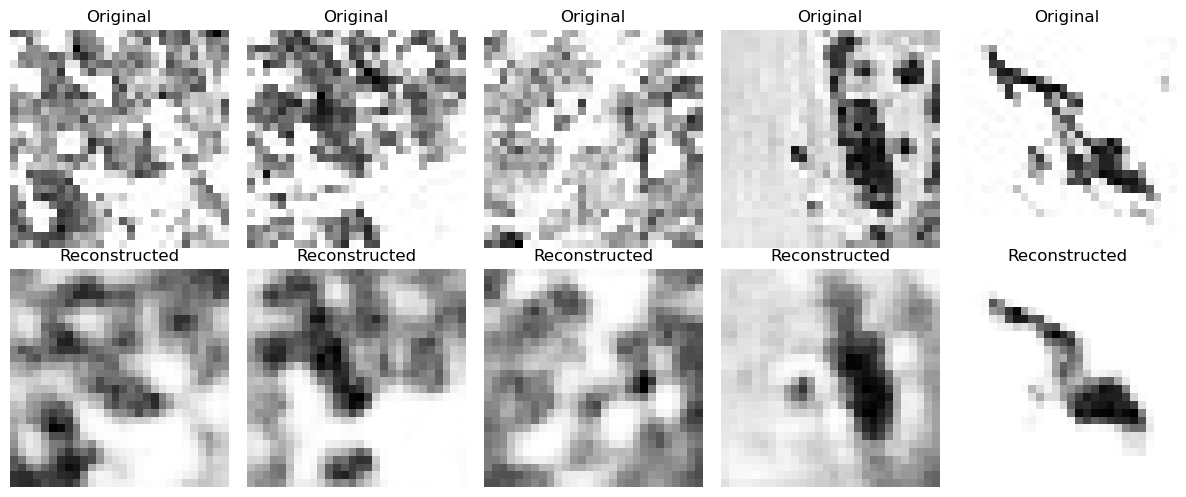

In [22]:
# visualisasi reconstruction vs original
n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(
        reconstructed_oil[i].squeeze(),
        cmap='gray'
    )
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# Hitung SSIM
from skimage.metrics import structural_similarity as ssim

ssim_scores_oil = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        reconstructed_oil[i].squeeze(),
        data_range=1.0
    )

    ssim_scores_oil.append(score)

average_ssim_oil = np.mean(
    ssim_scores_oil
)

print(
    "Average SSIM Improved:",
    average_ssim_oil
)

Average SSIM Improved: 0.5977766387310224


In [24]:
# perbandingan baseline vs improved
baseline_ssim = 0.48271439672874983

print("="*40)
print("Baseline SSIM :", baseline_ssim)
print("Improved SSIM :", average_ssim_oil)
print("="*40)

Baseline SSIM : 0.48271439672874983
Improved SSIM : 0.5977766387310224


## Evaluasi Autoencoder yang Dimodifikasi

Setelah dilakukan modifikasi arsitektur Autoencoder dan tuning hyperparameter, diperoleh nilai rata-rata **Structural Similarity Index (SSIM) sebesar 0.5978** pada data test.

Jika dibandingkan dengan model baseline yang memperoleh nilai SSIM sebesar **0.4827**, model yang dimodifikasi berhasil meningkatkan performa sebesar **0.1151** atau sekitar **23.84%**.

Peningkatan tersebut menunjukkan bahwa arsitektur yang lebih dalam mampu menghasilkan representasi laten yang lebih informatif dibandingkan model baseline. Penambahan layer konvolusi hingga 256 filter memungkinkan model mempelajari fitur visual yang lebih kompleks, terutama pola tekstur dan struktur yang terdapat pada gambar Oil Gas Field.

Selain itu, penggunaan Batch Normalization membantu menstabilkan proses training, sedangkan Dropout membantu mengurangi risiko overfitting. Penggunaan fungsi loss MAE juga memberikan kemampuan yang lebih baik dalam mempertahankan detail visual pada proses rekonstruksi gambar.

Hasil ini menunjukkan bahwa modifikasi arsitektur dan tuning hyperparameter berhasil meningkatkan kualitas rekonstruksi gambar sehingga informasi yang dipertahankan setelah proses dimension reduction menjadi lebih representatif dibandingkan model baseline.


## Kesimpulan

Pada penelitian ini dilakukan proses dimension reduction menggunakan Autoencoder pada dataset Oil Gas Field dari Overhead-MNIST.

Model baseline berhasil mengurangi dimensi gambar dari 784 fitur menjadi representasi laten berukuran 128 fitur dan menghasilkan nilai SSIM sebesar **0.4827**.

Selanjutnya dilakukan modifikasi arsitektur dengan menambahkan layer konvolusi yang lebih dalam, Batch Normalization, Dropout, serta tuning hyperparameter. Model yang dimodifikasi berhasil meningkatkan nilai SSIM menjadi **0.5978**.

Peningkatan sebesar **23.84%** menunjukkan bahwa model yang dimodifikasi mampu mempertahankan lebih banyak informasi visual dibandingkan model baseline. Dengan demikian, Autoencoder yang dimodifikasi dapat dianggap sebagai model yang lebih baik untuk melakukan dimension reduction pada dataset Oil Gas Field.
